##Kiểm tra dữ liệu và tiền xử lý

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

####Đọc dữ liệu

In [2]:
ST = pd.read_csv('/content/train.csv')
ST

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


###Kiểm tra dữ liệu

In [3]:
ST.dtypes

,0
date,object
store,int64
item,int64
sales,int64


####Kiểm tra missing values

In [4]:
#Không có missing values
ST.isna().sum()

,0
date,0
store,0
item,0
sales,0


####Kiểm tra dữ liệu trùng lặp

In [5]:
#Không có trùng lặp
ST.duplicated().sum()

np.int64(0)

####Chuyển đổi date

In [6]:
ST['date'] = pd.to_datetime(ST['date'])
ST = ST.sort_values(by=['store','item','date'])
ST

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


##Feature engineering

In [7]:
# Time features
ST['day'] = ST['date'].dt.day
ST['month'] = ST['date'].dt.month
ST['year'] = ST['date'].dt.year
ST['dayofweek'] = ST['date'].dt.dayofweek

# Lag features
ST['lag_7'] = ST.groupby(['store','item'])['sales'].shift(7)
ST['lag_14'] = ST.groupby(['store','item'])['sales'].shift(14)

# Rolling mean
ST['rolling_mean_7'] = ST.groupby(['store','item'])['sales'] \
    .transform(lambda x: x.shift(1).rolling(7).mean())
ST['rolling_mean_14'] = ST.groupby(['store','item'])['sales'] \
    .transform(lambda x: x.shift(1).rolling(14).mean())

# Rolling std (độ biến động)
ST['rolling_std_7'] = ST.groupby(['store','item'])['sales'] \
    .transform(lambda x: x.shift(1).rolling(7).std())
ST

,date,store,item,sales,day,month,year,dayofweek,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7
0,2013-01-01,1,1,13,1,1,2013,1,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,1,2013,2,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,3,1,2013,3,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,4,1,2013,4,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,5,1,2013,5,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,27,12,2017,2,51.0,67.0,61.000000,63.071429,13.576941
912996,2017-12-28,10,50,59,28,12,2017,3,63.0,72.0,62.714286,62.785714,12.841525
912997,2017-12-29,10,50,74,29,12,2017,4,75.0,72.0,62.142857,61.857143,12.915476
912998,2017-12-30,10,50,62,30,12,2017,5,70.0,52.0,62.000000,62.000000,12.754084


In [8]:
ST.isna().sum()

,0
date,0
store,0
item,0
sales,0
day,0
month,0
year,0
dayofweek,0
lag_7,3500
lag_14,7000


In [9]:
# Xóa dữ liệu null sau khi tạo lag
ST = ST.dropna()
ST

,date,store,item,sales,day,month,year,dayofweek,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7
14,2013-01-15,1,1,5,15,1,2013,1,9.0,13.0,9.714286,10.785714,1.799471
15,2013-01-16,1,1,7,16,1,2013,2,12.0,11.0,9.142857,10.214286,2.544836
16,2013-01-17,1,1,16,17,1,2013,3,9.0,14.0,8.428571,9.928571,2.299068
17,2013-01-18,1,1,7,18,1,2013,4,9.0,13.0,9.428571,10.071429,3.690399
18,2013-01-19,1,1,18,19,1,2013,5,7.0,10.0,9.142857,9.642857,3.804759
...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,27,12,2017,2,51.0,67.0,61.000000,63.071429,13.576941
912996,2017-12-28,10,50,59,28,12,2017,3,63.0,72.0,62.714286,62.785714,12.841525
912997,2017-12-29,10,50,74,29,12,2017,4,75.0,72.0,62.142857,61.857143,12.915476
912998,2017-12-30,10,50,62,30,12,2017,5,70.0,52.0,62.000000,62.000000,12.754084


##Exploratory Data Analysis (EDA)

#### Thống kê mô tả

In [10]:
total_sales = ST['sales'].sum()
mean_sales = ST['sales'].mean()
variance_sales = ST['sales'].var()
std_sales = ST['sales'].std()
print("Total Sales:", total_sales)
print("Mean:", mean_sales)
print("Variance:", variance_sales)
print("Standard Deviation:", std_sales)

Total Sales: 47497797
Mean: 52.42582450331126
Variance: 830.1158800218121
Standard Deviation: 28.81173163872335


####Tổng hợp theo tháng/tuần (resample)

In [11]:
# Tổng hợp theo tháng
monthly_sales = ST.resample('M', on='date')['sales'].sum()
monthly_sales

,sales
date,
2013-01-31,248189
2013-02-28,459417
2013-03-31,617382
2013-04-30,682274
2013-05-31,763242
2013-06-30,795597
2013-07-31,855922
2013-08-31,766761
2013-09-30,689907


In [12]:
# Tổng hợp theo tuần
weekly_sales = ST.resample('W', on='date')['sales'].sum()
weekly_sales

,sales
date,
2013-01-20,91204
2013-01-27,103298
2013-02-03,109027
2013-02-10,114566
2013-02-17,115261
...,...
2017-12-03,187286
2017-12-10,154400
2017-12-17,155296


####Histogram

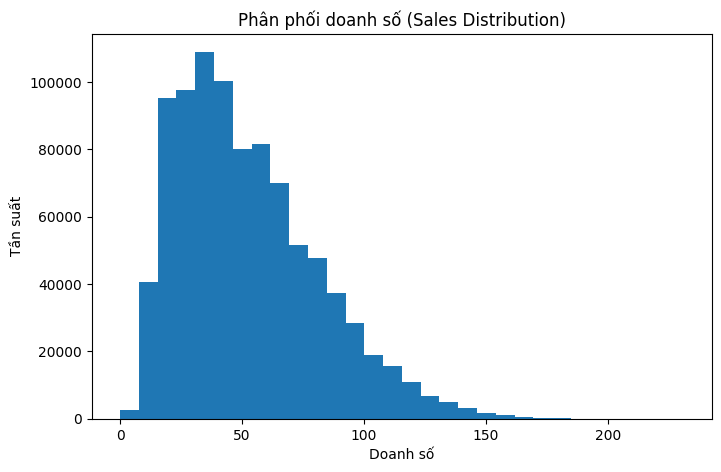

In [296]:
plt.figure(figsize=(8,5))
plt.hist(ST['sales'], bins=30)

plt.title("Phân phối doanh số (Sales Distribution)")
plt.xlabel("Doanh số")
plt.ylabel("Tần suất")

plt.show()

####Boxplot

In [15]:
Q1 = ST['sales'].quantile(0.25)
Q3 = ST['sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc outliers
outliers = ST[
    (ST['sales'] < lower_bound) |
    (ST['sales'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("Number of Outliers:", len(outliers))

Lower Bound: -30.0
Upper Bound: 130.0
Number of Outliers: 11967


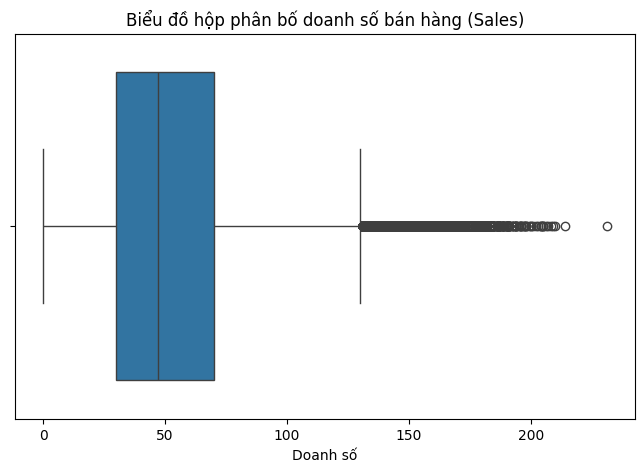

In [297]:
plt.figure(figsize=(8,5))
sns.boxplot(x=ST['sales'])

plt.title('Biểu đồ hộp phân bố doanh số bán hàng (Sales)')
plt.xlabel('Doanh số')
plt.show()

####Phân tích mùa vụ (Seasonality)

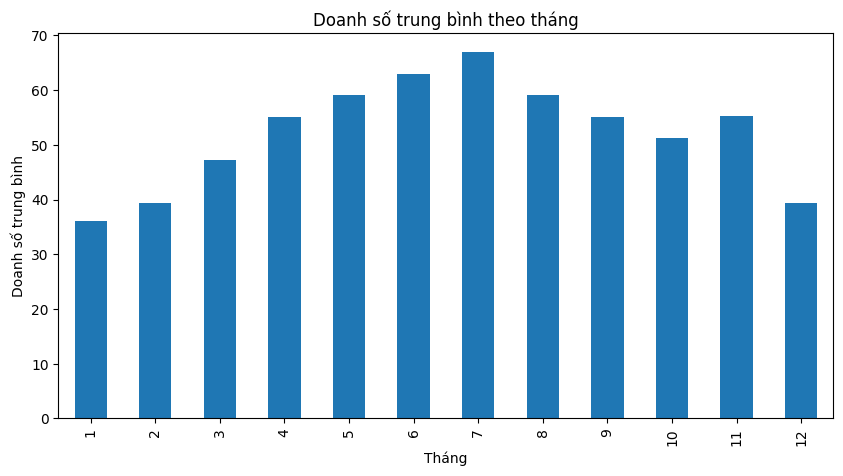

In [18]:
# Theo tháng
monthly_pattern = ST.groupby('month')['sales'].mean()

monthly_pattern.plot(kind='bar', figsize=(10,5))
plt.title("Doanh số trung bình theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Doanh số trung bình")
plt.show()

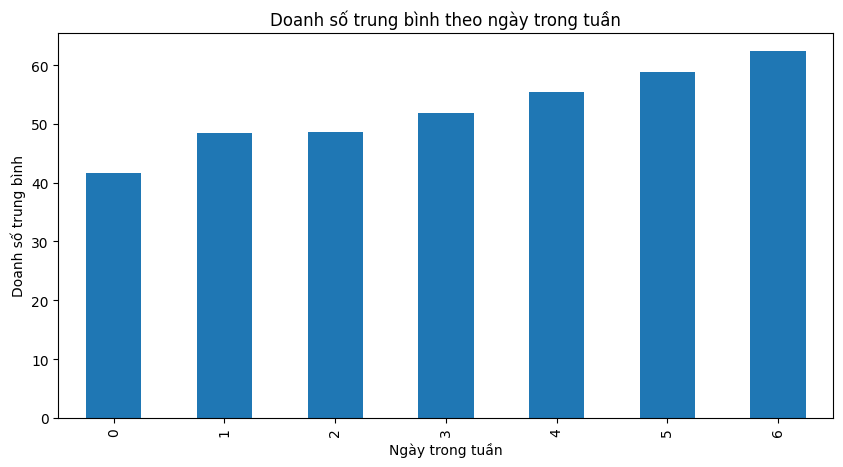

In [19]:
# Theo ngày trong tuần
weekday_pattern = ST.groupby('dayofweek')['sales'].mean()

weekday_pattern.plot(kind='bar', figsize=(10,5))
plt.title("Doanh số trung bình theo ngày trong tuần")
plt.xlabel("Ngày trong tuần")
plt.ylabel("Doanh số trung bình")
plt.show()

####Pareto

In [20]:
# Tổng doanh số theo sản phẩm
pareto = ST.groupby('item')['sales'].sum().reset_index()

# Sắp xếp giảm dần
pareto = pareto.sort_values(by='sales', ascending=False)

# Tính phần trăm doanh số
pareto['sales_percent'] = (
    pareto['sales'] / pareto['sales'].sum()
) * 100

# Tính phần trăm tích lũy
pareto['cum_percent'] = pareto['sales_percent'].cumsum()

# Phân nhóm ABC theo nguyên lý Pareto
def classify_abc(x):
    if x <= 80:
        return 'A'
    elif x <= 95:
        return 'B'
    else:
        return 'C'

pareto['category'] = pareto['cum_percent'].apply(classify_abc)
pareto

,item,sales,sales_percent,cum_percent,category
14,15,1600450,3.369525,3.369525,A
27,28,1597639,3.363607,6.733131,A
12,13,1533050,3.227623,9.960755,A
17,18,1532319,3.226084,13.186839,A
24,25,1466825,3.088196,16.275035,A
44,45,1465157,3.084684,19.359719,A
37,38,1464046,3.082345,22.442064,A
21,22,1463588,3.081381,25.523445,A
35,36,1400418,2.948385,28.471830,A
7,8,1399000,2.945400,31.417230,A


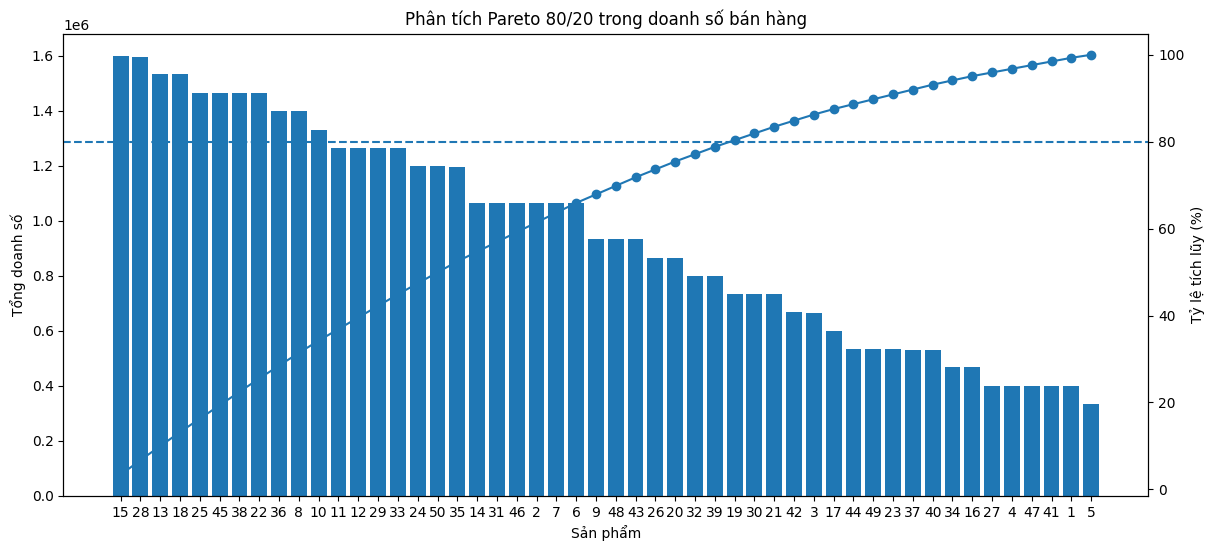

In [23]:
fig, ax1 = plt.subplots(figsize=(14,6))
# Biểu đồ cột doanh số
ax1.bar(
    pareto['item'].astype(str),
    pareto['sales']
)
ax1.set_xlabel('Sản phẩm')
ax1.set_ylabel('Tổng doanh số')
# Biểu đồ đường tỷ lệ tích lũy
ax2 = ax1.twinx()
ax2.plot(
    pareto['item'].astype(str),
    pareto['cum_percent'],
    marker='o'
)
ax2.set_ylabel('Tỷ lệ tích lũy (%)')
# Đường ngưỡng 80%
ax2.axhline(80, linestyle='--')
plt.title('Phân tích Pareto 80/20 trong doanh số bán hàng')
plt.xticks(rotation=90)
plt.show()

In [131]:
ST['id'] = range(len(ST))

In [132]:
# Giữ bản gốc
ST_raw = ST.copy()

# Tạo bản model riêng
ST_model = pd.get_dummies(ST_raw, columns=['store','item'])

####Train/Test Split (Time series)

In [133]:
# Split theo thời gian
train = ST_model[ST_model['date'] < '2017-01-01']
test = ST_model[ST_model['date'] >= '2017-01-01']
# Tạo X, y
X_train = train.drop(columns=['sales','date','id'])
y_train = train['sales']

X_test = test.drop(columns=['sales','date','id'])
y_test = test['sales']

####Train Random forest

In [135]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

####Evaluation (test)

In [151]:
y_pred = model.predict(X_test)

result_eval = test.copy()
result_eval['forecast'] = y_pred

####Đánh giá model

In [293]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAPE:", mape(y_test, y_pred))

MAE: 6.331564478234237
RMSE: 8.242481677990952
MAPE: 13.022738636769226


####Giả lập tồn kho

In [232]:
# Tính doanh số trung bình
avg_sales = ST_raw.groupby(['store','item'])['sales'].mean().reset_index()
avg_sales.rename(columns={'sales':'avg_daily_sales'}, inplace=True)

In [233]:
# BUFFER STOCK - 10 NGÀY
avg_sales['inventory'] = avg_sales['avg_daily_sales'] * 10

In [246]:
# Phân loại fast/medium/slow
item_avg = ST_raw.groupby('item')['sales'].mean()

fast_threshold = item_avg.quantile(0.7)
slow_threshold = item_avg.quantile(0.3)

def classify(avg):
    if avg >= fast_threshold:
        return "Fast-moving"
    elif avg >= slow_threshold:
        return "Medium-moving"
    else:
        return "Slow-moving"

avg_sales['category'] = avg_sales['avg_daily_sales'].apply(classify)

####Tạo future

In [235]:
future = ST_raw[['store','item']].drop_duplicates().copy()

future = pd.concat([
    future.assign(day_ahead=i)
    for i in range(1, 8)
])

In [247]:
future = ST_raw[['store','item']].drop_duplicates().copy()

future = future.loc[future.index.repeat(7)]
future['day_ahead'] = list(range(1,8)) * (len(future)//7)

####Tạo date feature

In [248]:
future['date'] = pd.to_datetime('today') + pd.to_timedelta(future['day_ahead'], unit='D')
future['year'] = future['date'].dt.year
future['month'] = future['date'].dt.month
future['day'] = future['date'].dt.day
future['dayofweek'] = future['date'].dt.dayofweek

####Save store với item

In [249]:
future_base = future[['store','item']].copy()

####Encode future

In [250]:
future_model = pd.get_dummies(future, columns=['store','item'])

future_model = future_model.reindex(columns=features, fill_value=0)

####Predict future

In [251]:
future_model['forecast'] = model.predict(future_model)

####Restore store-item

In [252]:
future_model[['store','item']] = future_base.values

####Forecast 7 day

In [253]:
forecast = future_model.groupby(['store','item'])['forecast'].sum().reset_index()

forecast.rename(columns={'forecast':'forecast_7days'}, inplace=True)

In [259]:
forecast['forecast_7days'] = forecast['forecast_7days'] * 10

####Merge inventory + safety stock

In [284]:
result = forecast.merge(
    avg_sales[['store','item','inventory']],
    on=['store','item'],
    how='left'
)

result['order_qty'] = (
    result['forecast_7days'] - result['inventory']
).clip(lower=0)

In [285]:
def priority(row):
    if row['order_qty'] > row['inventory']:
        return "High"
    elif row['order_qty'] > row['inventory'] * 0.5:
        return "Medium"
    else:
        return "Low"

result['priority'] = result.apply(priority, axis=1)

####Output

In [286]:
result[['store','item','forecast_7days','inventory','order_qty','priority']]

,store,item,forecast_7days,inventory,order_qty,priority
0,1,1,698.932747,200.424945,498.507802,High
1,1,2,681.993539,533.222958,148.770581,Low
2,1,3,681.993539,333.289183,348.704355,High
3,1,4,696.583167,200.220751,496.362417,High
4,1,5,636.894964,166.721854,470.173109,High
...,...,...,...,...,...,...
495,10,46,669.539182,662.477925,7.061257,Low
496,10,47,678.672460,248.377483,430.294977,High
497,10,48,669.539182,580.099338,89.439844,Low
498,10,49,674.279182,331.390728,342.888454,High


In [292]:
result.groupby(['store','item'])['order_qty'] \
       .sum().reset_index() \
       .sort_values('order_qty', ascending=False) \
       .head(10)

,store,item,order_qty
300,7,1,539.798856
303,7,4,537.616960
346,7,47,529.724738
200,5,1,528.939191
315,7,16,527.085331
340,7,41,527.027474
203,5,4,526.666797
326,7,27,526.339229
246,5,47,522.234862
253,6,4,518.970684


####Top item nên nhập

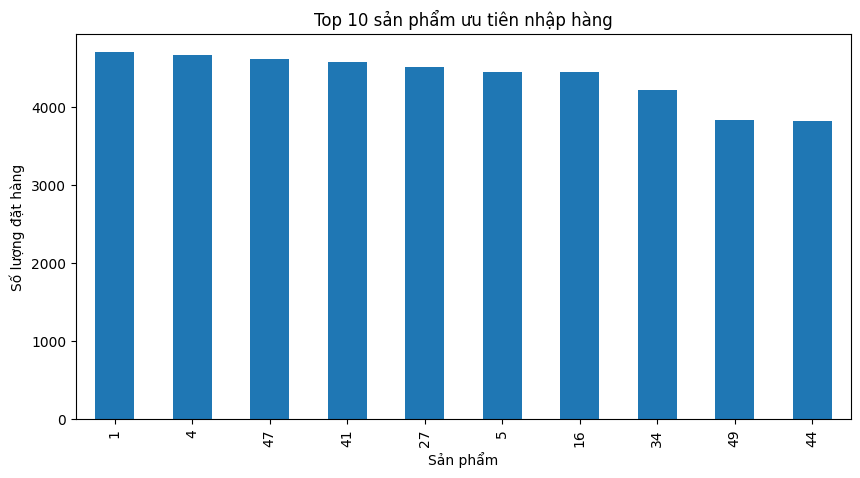

In [295]:
top_items = result.groupby('item')['order_qty'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_items.plot(kind='bar')
plt.title('Top 10 sản phẩm ưu tiên nhập hàng')
plt.xlabel('Sản phẩm')
plt.ylabel('Số lượng đặt hàng')
plt.show()